In [1]:
print('Welcome to pytho')


Welcome to pytho


In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np

df= pd.read_csv('C:/VideoGamesProject-main/VideoGamesSales.csv')
#df=df[df.duplicated()]
df=df.drop_duplicates()
#df.info()
df['Region']=df['Region'].fillna('North')   
#df=df[df['Region'].isnull()]
#df.shape[0]
#df.tail(100)
df['NA_Sales']=df['NA_Sales'].replace('[$]','',regex=True)
df['NA_Sales']=pd.to_numeric(df['NA_Sales'],errors='coerce')
Average_sales=df['NA_Sales'].mean()
Average_sales=int(Average_sales)
df['NA_Sales']=df['NA_Sales'].fillna(Average_sales)

df['Country']=df['Country'].replace({'USA':'United States'})
df['Country']=df['Country'].str.title()
#df=df[df['Country']=='Australia']
df=df.rename(columns={'NA_Sales':'National Sales','Global_Sales':'Global Sales','NA_Profit':'National profit','Global_Profit':'Global Profit'})

sales_cap=df['National Sales'].quantile(0.95)
df['National Sales']=np.where(df['National Sales']>sales_cap,sales_cap,df['Global Sales'])
df

,Rank,Name,Platform,Year,Month,Genre,Publisher,Country,City,State,Region,National Sales,Global Sales,National profit,Global Profit
0,1,Wii Sports,Wii,2010,Jan,Sports,Nintendo,United States,Fairfield,California,West,2.07,82.74,12.447,24.822
1,2,Super Mario Bros.,NES,2010,Feb,Platform,Nintendo,United States,Edmonds,Washington,West,2.07,40.24,8.724,12.072
2,3,Mario Kart Wii,Wii,2010,Mar,Racing,Nintendo,United States,Louisville,Kentucky,South,2.07,35.82,4.755,10.746
3,4,Wii Sports Resort,Wii,2010,Apr,Sports,Nintendo,United States,Round Rock,Texas,Central,2.07,33.00,4.725,9.900
4,5,Pokemon Red/Pokemon Blue,GB,2010,May,Role-Playing,Nintendo,United States,Nashville,Tennessee,South,2.07,31.37,3.381,9.411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5904,5890,Crazy Taxi: Catch a Ride,GBA,2017,Sep,Racing,THQ,Australia,Sydney,New South Wales,West,0.30,0.30,0.063,0.090
5905,5891,MySims Party,DS,2017,Oct,Simulation,Electronic Arts,Australia,Sydney,New South Wales,West,0.30,0.30,0.045,0.090
5906,5892,Harry Potter and the Order of the Phoenix,X360,2017,Nov,Action,Electronic Arts,Australia,Sydney,New South Wales,West,0.30,0.30,0.072,0.090
5907,5893,Skylanders: SuperChargers,PS4,2017,Dec,Action,Activision,Australia,Sydney,New South Wales,West,0.30,0.30,0.051,0.090


In [5]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
#Create a bar Chart
National_Sales=df.groupby(['Region','Country'])['National Sales'].sum().reset_index().sort_values(by='National Sales',ascending=True)
National_Sales



,Region,Country,National Sales
1,East,Australia,2.86
3,North,Australia,28.28
6,South,Australia,31.35
4,North,United States,34.81
5,Other,Australia,57.51
7,South,United States,733.06
0,Central,United States,1057.62
2,East,United States,1290.45
8,West,Australia,1348.25
9,West,United States,1458.82


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

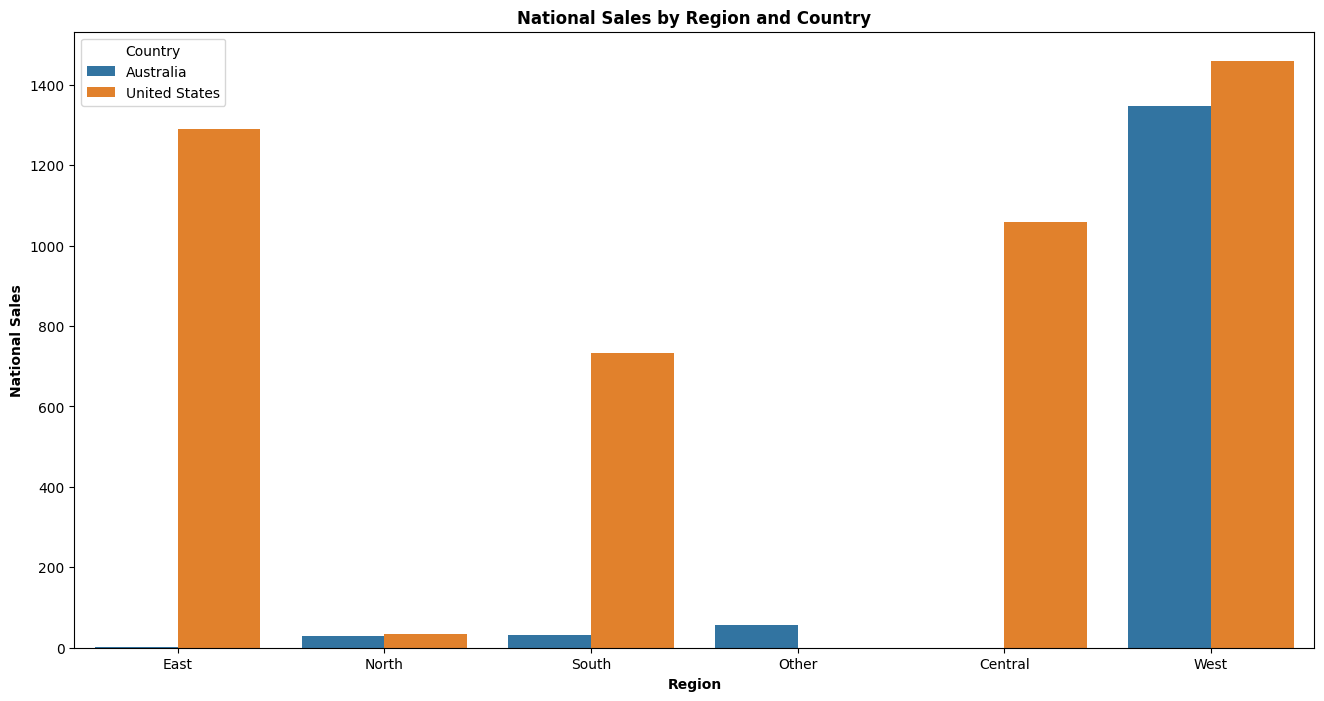

In [33]:
plt.figure(figsize=(16,8))

sns.barplot(
    data=National_Sales,
    x='Region',
    y='National Sales',
    hue='Country'
)

plt.title('National Sales by Region and Country',fontweight='bold')
plt.xlabel('Region',fontweight='bold')
plt.ylabel('National Sales',fontweight='bold')
plt.show()

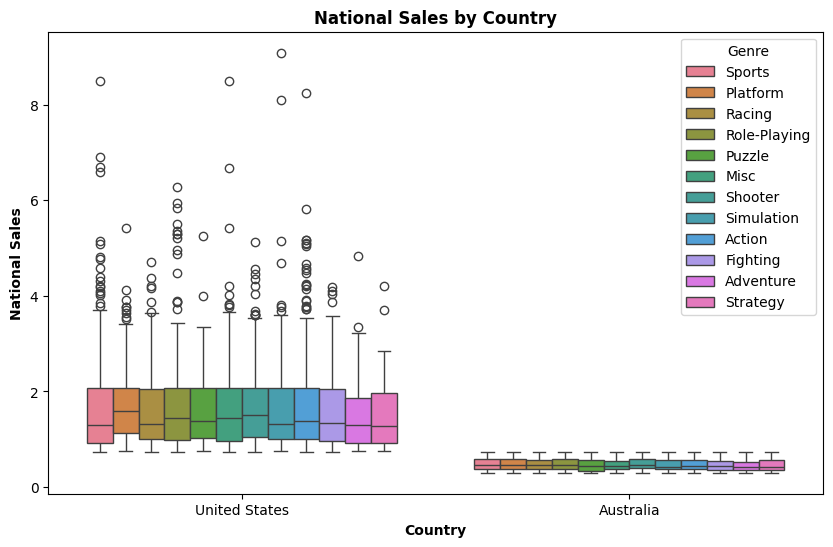

In [34]:
#Creat Box Plot
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Country',
    y='National Sales',
    data=df,
    hue='Genre'
)

plt.title('National Sales by Country', fontweight='bold')
plt.xlabel('Country', fontweight='bold')
plt.ylabel('National Sales', fontweight='bold')
plt.show()

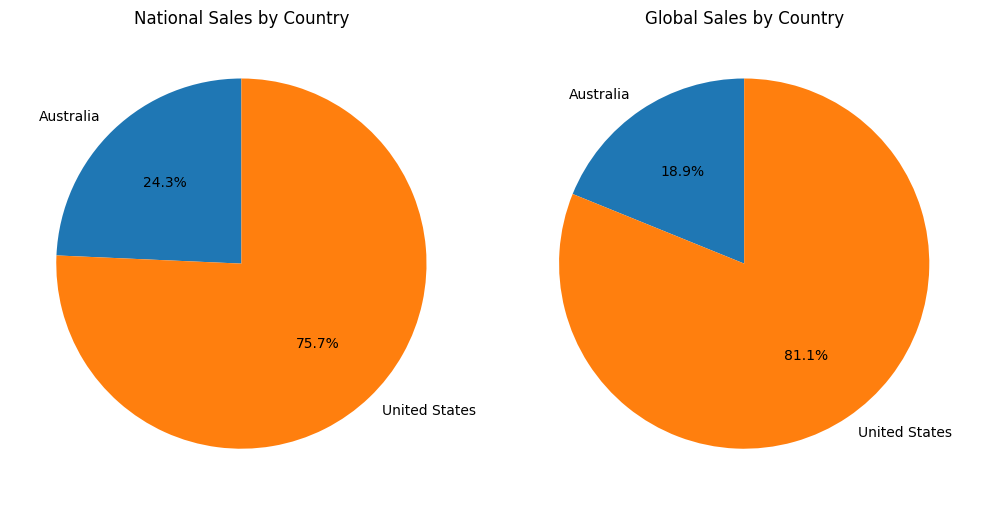

In [35]:
#create a pie chart
sales=df.groupby(['Country'])[['National Sales','Global Sales']].sum().reset_index()
Country=sales['Country']
National_Sales=Sales['National Sales']
Global_Sales=Sales['Global Sales']


fig, axs = plt.subplots(1, 2, figsize=(10, 7))

axs[0].pie(National_Sales,
           labels=Country,
           autopct='%1.1f%%',
           startangle=90)
axs[0].set_title('National Sales by Country')

axs[1].pie(Global_Sales,
           labels=Country,
           autopct='%1.1f%%',
           startangle=90)
axs[1].set_title('Global Sales by Country')

plt.tight_layout()
plt.show()


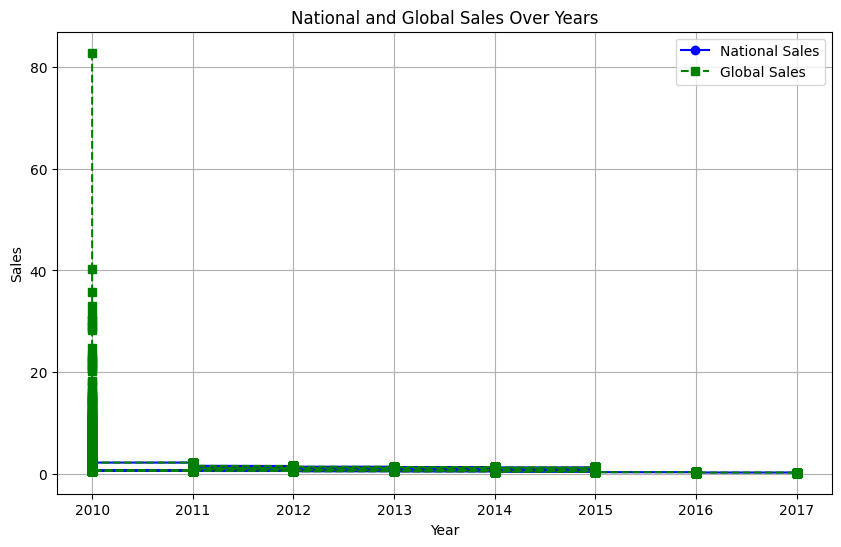

In [36]:
#Create a line chart
plt.figure(figsize=(10,6))

#Line for National Sales
plt.plot(df['Year'],
         df['National Sales'],
         marker='o',
         linestyle='-',
         color='b',
         label='National Sales')

#Line for Global Sales
plt.plot(df['Year'],
         df['Global Sales'],
         marker='s',
         linestyle='--',
         color='g',
         label='Global Sales')

#Adding titles and LabeLs
plt.title ('National and Global Sales Over Years')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.legend()

#Display the line chart
plt.grid(True)
plt.show()



